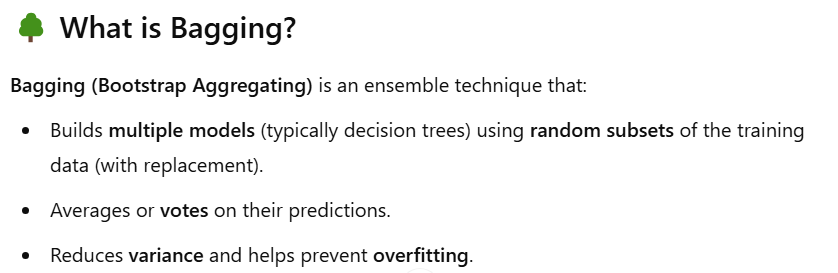


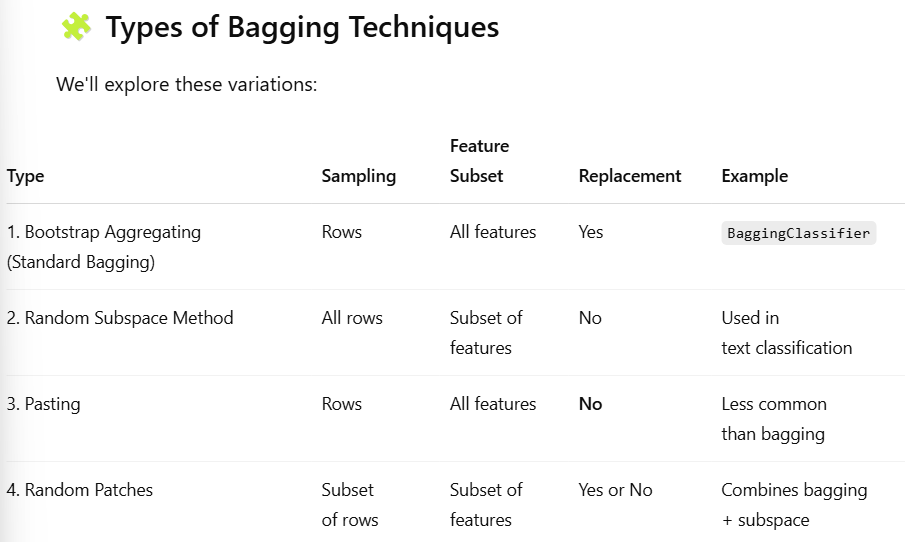

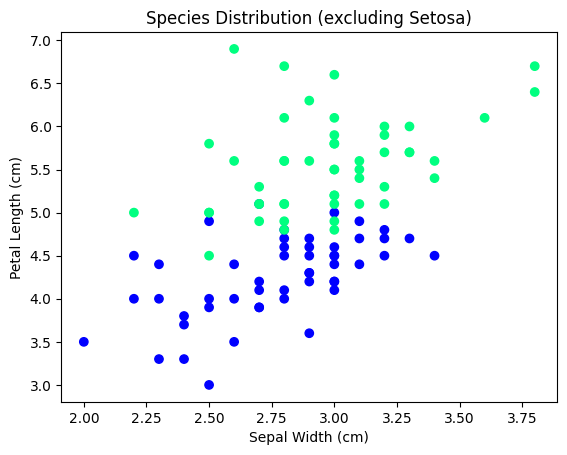

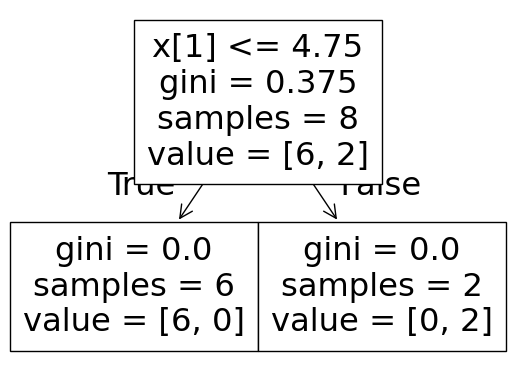

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


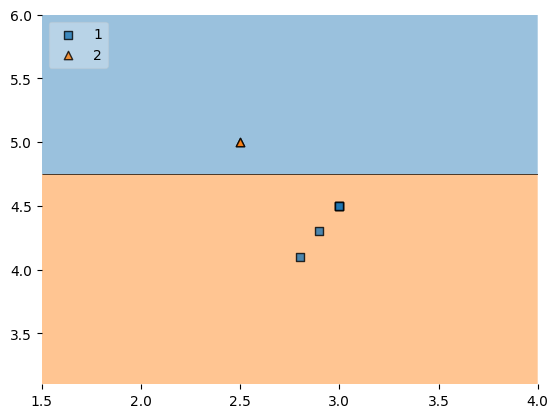

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy on validation set: 0.8


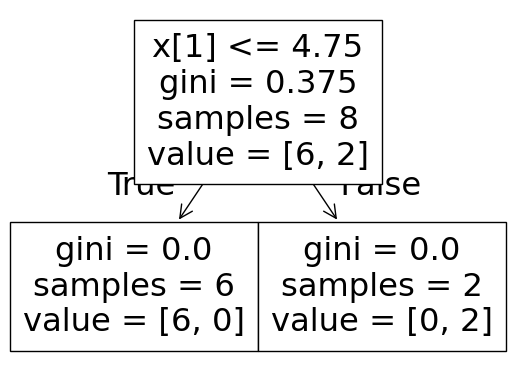

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


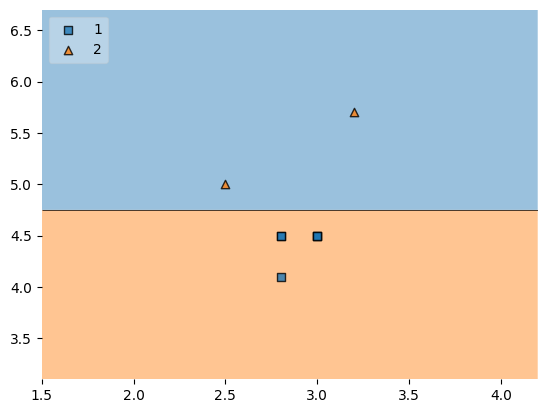

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy on validation set: 0.8


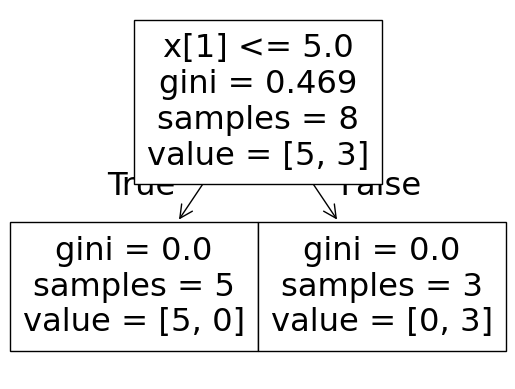

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


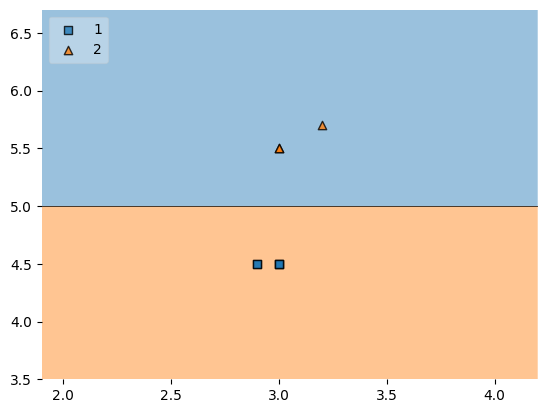

Accuracy on validation set: 0.8
Predictor 1: [2]
Predictor 2: [2]
Predictor 3: [1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

# Load iris dataset from sklearn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['Species'] = iris.target

# Map target to actual species name for clarity (optional)
df['Species_Name'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Drop setosa class (label 0) and choose specific features
df = df[df['Species'] != 0][['sepal width (cm)', 'petal length (cm)', 'Species']]

# Quick visualization
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c=df['Species'], cmap='winter')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Species Distribution (excluding Setosa)')
plt.show()

# Sampling for training, validation, and test
df = df.sample(100, random_state=42)
df_train = df.iloc[:60].sample(10, random_state=1)
df_val = df.iloc[60:80].sample(5, random_state=2)
df_test = df.iloc[80:].sample(5, random_state=3)

X_test = df_val.iloc[:, 0:2].values
y_test = df_val['Species'].values

# Function to train and evaluate
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    plt.show()
    y_pred = clf.predict(X_test)
    print("Accuracy on validation set:", accuracy_score(y_test, y_pred))

### Bagging Example
# Tree 1
df_bag1 = df_train.sample(8, replace=True, random_state=10)
X1, y1 = df_bag1.iloc[:, 0:2], df_bag1['Species']
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1, X1, y1)

# Tree 2
df_bag2 = df_train.sample(8, replace=True, random_state=11)
X2, y2 = df_bag2.iloc[:, 0:2], df_bag2['Species']
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X2, y2)

# Tree 3
df_bag3 = df_train.sample(8, replace=True, random_state=12)
X3, y3 = df_bag3.iloc[:, 0:2], df_bag3['Species']
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X3, y3)

# Prediction on a custom sample
sample = np.array([2.2, 5.0]).reshape(1, -1)
print("Predictor 1:", dt_bag1.predict(sample))
print("Predictor 2:", dt_bag2.predict(sample))
print("Predictor 3:", dt_bag3.predict(sample))


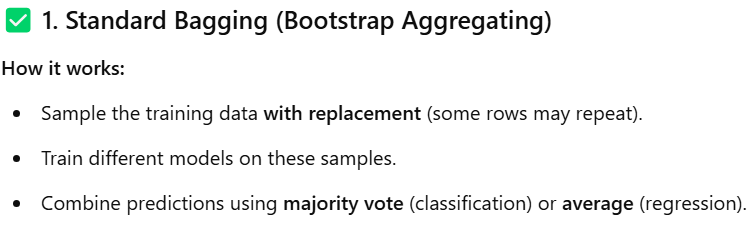

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),
    n_estimators=10,  # number of trees
    bootstrap=True,   # with replacement
    random_state=42
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)


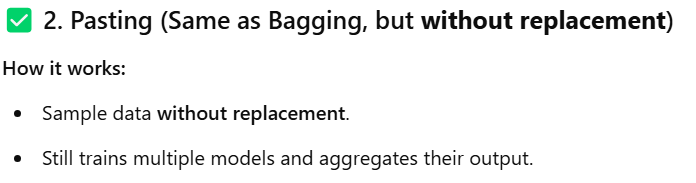

In [ ]:
bag_clf = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),
    n_estimators=10,
    bootstrap=False,  # no replacement → Pasting
    random_state=42
)
bag_clf.fit(X_train, y_train)


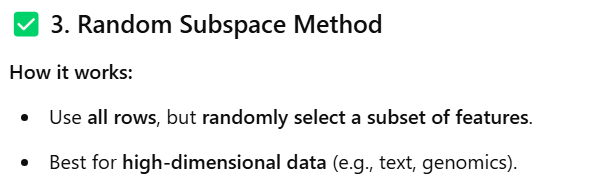

In [ ]:
bag_clf = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),
    n_estimators=10,
    max_features=0.5,     # 50% of features used per model
    bootstrap=False,      # no row sampling
    bootstrap_features=True  # select random feature subset
)
bag_clf.fit(X_train, y_train)


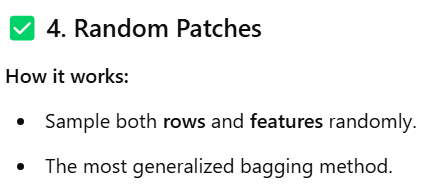

In [ ]:
bag_clf = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),
    n_estimators=10,
    bootstrap=True,
    bootstrap_features=True,
    max_samples=0.8,   # 80% rows
    max_features=0.5   # 50% features
)
bag_clf.fit(X_train, y_train)


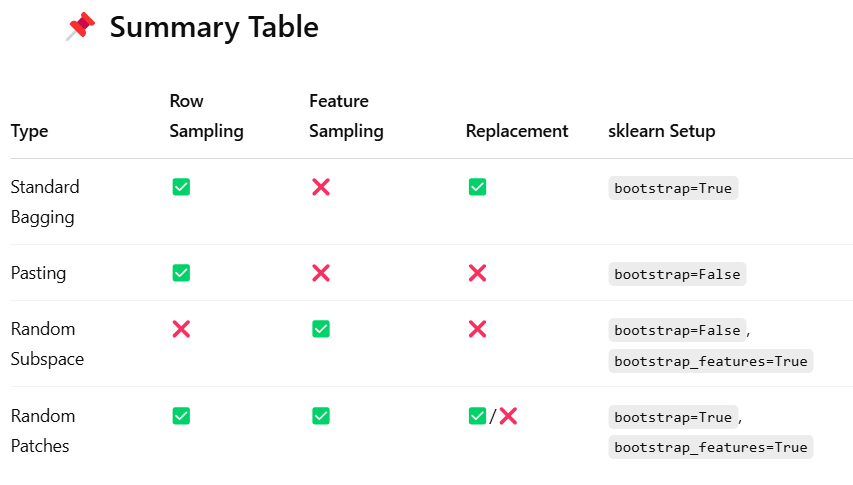